In [7]:
#ДЗ
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

Формат: (225, 225) | Мин: 0 | Макс: 255


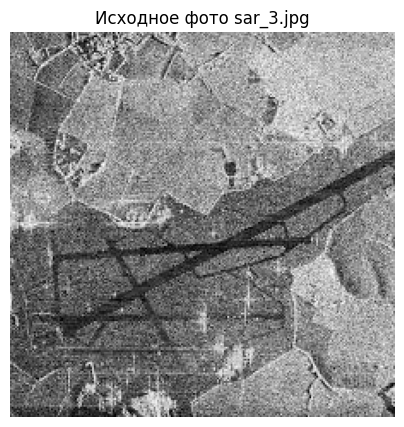

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Загружаем фотку
img = cv2.imread('sar_3.jpg', cv2.IMREAD_GRAYSCALE)

print(f"Формат: {img.shape} | Мин: {img.min()} | Макс: {img.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title("Исходное фото sar_3.jpg")
plt.axis('off')
plt.show()

Всего отрезков: 222
Самый протяженный: (2, 224, 223, 3)
Длина: 312.54 px | Угол: -45.00°


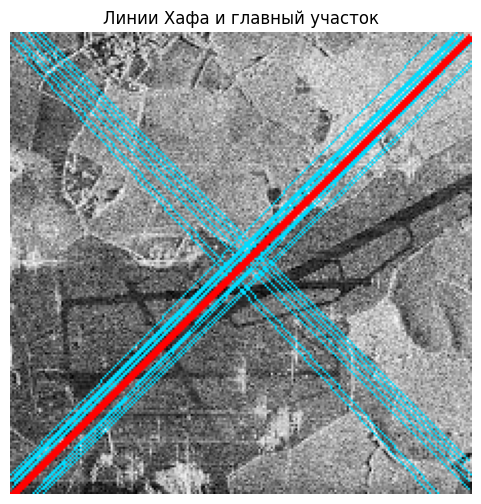

In [9]:
#Поиск границ Canny
edges = cv2.Canny(img, 50, 150, apertureSize=3)

#Преобразование Хафа для поиска отрезков
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=30, minLineLength=80, maxLineGap=20)

if lines is None:
    raise RuntimeError("Линии не обнаружены")

#Формируем список и считаем их длину
items = []
for item in lines.reshape(-1, 4):
    x1, y1, x2, y2 = map(int, item)
    l = np.hypot(x2 - x1, y2 - y1)
    a = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    items.append((l, a, (x1, y1, x2, y2)))

#Сортировка по убыванию длины
items.sort(key=lambda item: item[0], reverse=True)
top_len, top_ang, top_pts = items[0]
px1, py1, px2, py2 = top_pts

print(f"Всего отрезков: {len(items)}")
print(f"Самый протяженный: {top_pts}")
print(f"Длина: {top_len:.2f} px | Угол: {top_ang:.2f}°")

#Рисуем найденные линии (первые 20 голубым, самую длинную красной)
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
for _, _, (lx1, ly1, lx2, ly2) in items[:20]:
    cv2.line(vis, (lx1, ly1), (lx2, ly2), (0, 220, 255), 1)

cv2.line(vis, (px1, py1), (px2, py2), (255, 0, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.title("Линии Хафа и главный участок")
plt.axis('off')
plt.show()

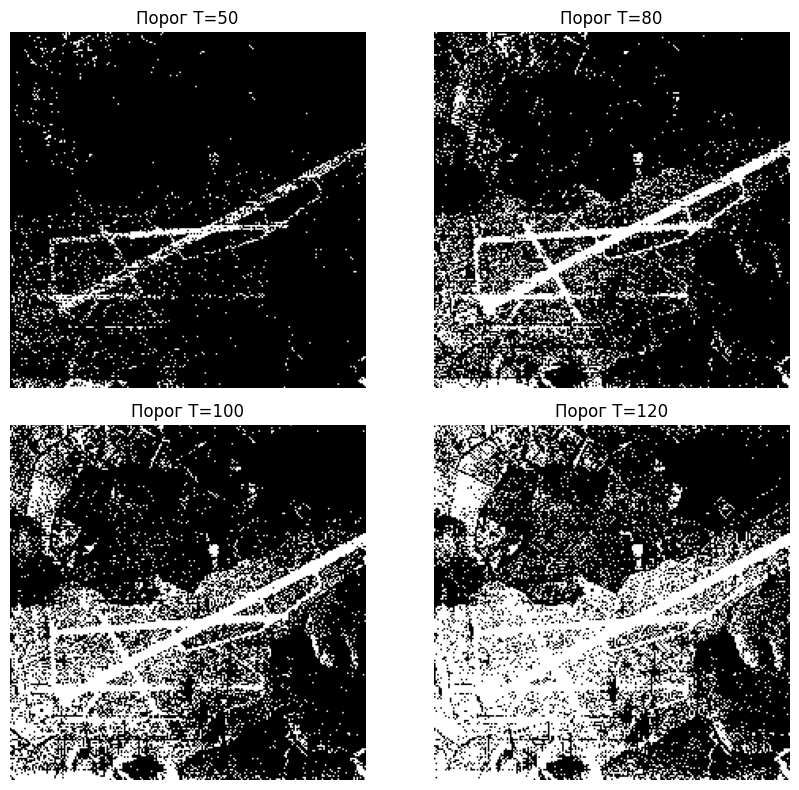

Оптимальный порог Отсу: 129


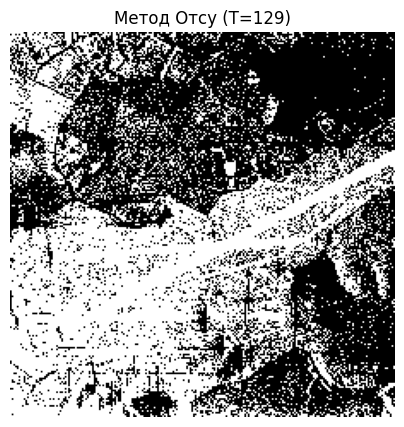

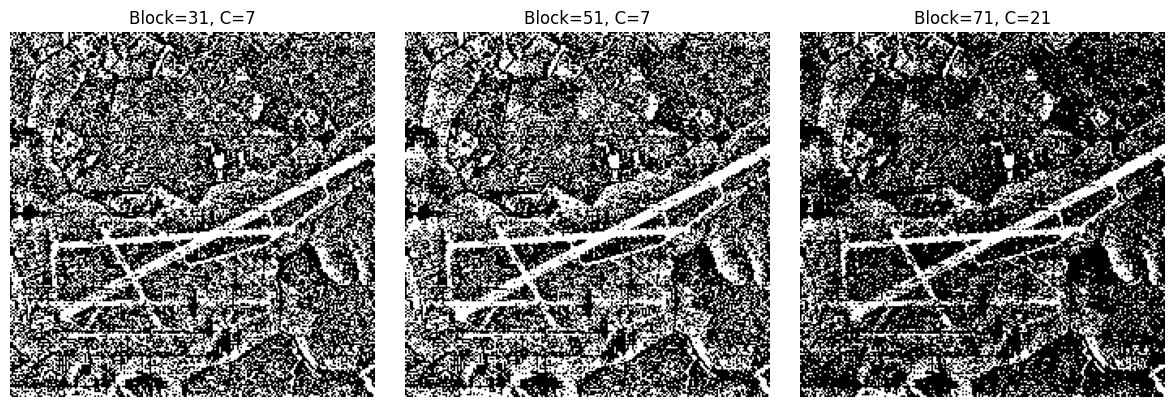

In [10]:
#Ручная бинаризация с разными порогами инвертированная
th_list = [50, 80, 100, 120]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for ax, T in zip(axes.ravel(), th_list):
    _, bin_img = cv2.threshold(img, T, 255, cv2.THRESH_BINARY_INV)
    ax.imshow(bin_img, cmap='gray')
    ax.set_title(f"Порог T={T}")
    ax.axis('off')

plt.tight_layout()
plt.show()

#Пороговый метод Отсу автоматическая
val_otsu, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Оптимальный порог Отсу: {val_otsu:.0f}")

plt.figure(figsize=(5, 5))
plt.imshow(img_otsu, cmap='gray')
plt.title(f"Метод Отсу (T={val_otsu:.0f})")
plt.axis('off')
plt.show()

#Адаптивная бинаризация с разным размером блока
params = [(31, 7), (51, 7), (71, 21)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (b, c) in zip(axes, params):
    adp = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, b, c)
    ax.imshow(adp, cmap='gray')
    ax.set_title(f"Block={b}, C={c}")
    ax.axis('off')

plt.tight_layout()
plt.show()

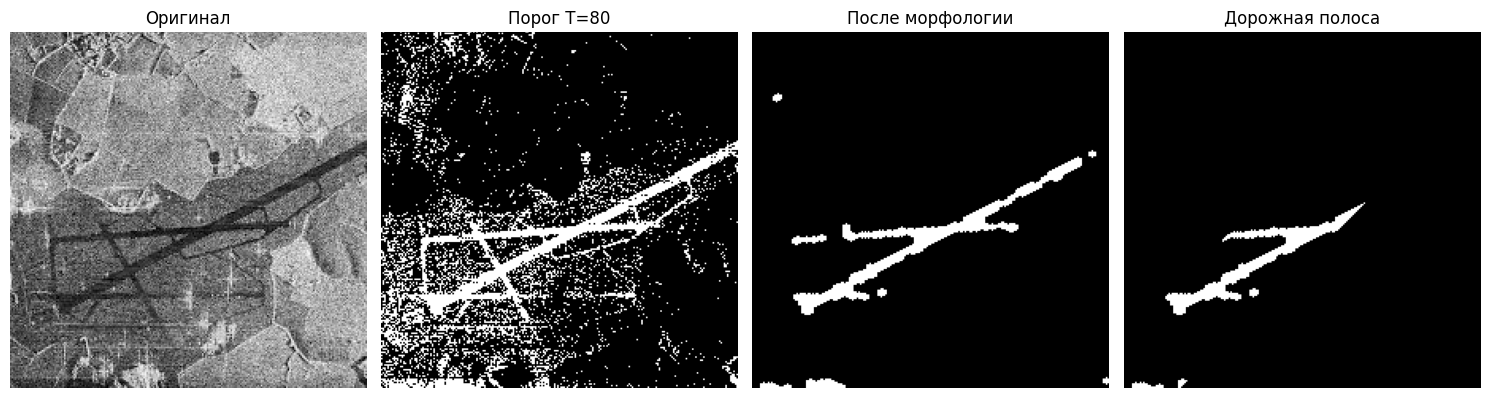

In [11]:
#Бинаризация для дорожного покрытия
cut_th = 80
_, raw_road = cv2.threshold(img, cut_th, 255, cv2.THRESH_BINARY_INV)

#Морфологическая обработка
k_e = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
clean = cv2.morphologyEx(raw_road, cv2.MORPH_OPEN, k_e)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_e)

#Строим ROI вокруг главной линии Хафа
roi_m = np.zeros_like(img)
cv2.line(roi_m, (px1, py1), (px2, py2), 255, 45)

#Финальное выделение дороги через пересечение с маской
final_road = cv2.bitwise_and(clean, roi_m)

#Отрисовка этапов
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ["Оригинал", f"Порог T={cut_th}", "После морфологии", "Дорожная полоса"]
imgs = [img, raw_road, clean, final_road]

for ax, i, t in zip(axes, imgs, titles):
    ax.imshow(i, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()

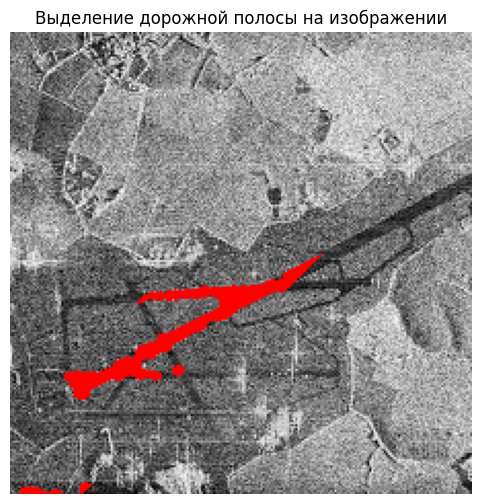

Порог дороги: 80
Ширина полосы маски: 45 px


In [12]:
#Подсветка зоны
res = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
res[final_road > 0] = [255, 0, 0]

plt.figure(figsize=(6, 6))
plt.imshow(res)
plt.title("Выделение дорожной полосы на изображении")
plt.axis('off')
plt.show()

print(f"Порог дороги: {cut_th}")
print("Ширина полосы маски: 45 px")